In [2]:
import pdfplumber
import pandas as pd

ruta_pdf = "./AuFe_SupportingInformation_30junio26.pdf"
todas_las_tablas = []

print("--- EXTRAYENDO Y CONSOLIDANDO TABLAS DEL PDF ---")

with pdfplumber.open(ruta_pdf) as pdf:
    for num_pagina, pagina in enumerate(pdf.pages, 1):
        tablas_pagina = pagina.extract_tables()
        
        for idx_tabla, tabla in enumerate(tablas_pagina, 1):
            # Convertir la tabla del PDF a un DataFrame de pandas
            df_tabla = pd.DataFrame(tabla)
            
            # Limpieza básica: eliminar filas y columnas que estén 100% vacías
            df_tabla = df_tabla.dropna(how='all').dropna(axis=1, how='all')
            
            if not df_tabla.empty:
                # Guardamos metadatos de qué página y qué número de tabla era
                df_tabla['pdf_pagina'] = num_pagina
                df_tabla['pdf_tabla_idx'] = idx_tabla
                todas_las_tablas.append(df_tabla)

print(f"\n✔ ¡Extracción completada! Se procesaron {len(todas_las_tablas)} tablas válidas.")

# Vamos a inspeccionar la primera tabla que tenga datos para ver cómo luce
if todas_las_tablas:
    print("\n--- VISTA PREVIA DE LA PRIMERA TABLA DETECTADA (PÁGINA 8) ---")
    # Mostramos las primeras filas de la primera tabla encontrada
    display(todas_las_tablas[0].head(10))
else:
    print("No se pudieron consolidar las tablas.")


--- EXTRAYENDO Y CONSOLIDANDO TABLAS DEL PDF ---

✔ ¡Extracción completada! Se procesaron 35 tablas válidas.

--- VISTA PREVIA DE LA PRIMERA TABLA DETECTADA (PÁGINA 8) ---


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,pdf_pagina,pdf_tabla_idx
0,Species,NaN,NaN,,𝑑̅\nAu–Au,,,𝑑̅\nFe–Fe,,,...,𝑑̅\nO–O,,,𝑑̅\nC–H,,,𝑑̅\nO–H,,8,1
1,NaN,NaN,NaN,NaN,,NaN,NaN,,NaN,NaN,...,,NaN,NaN,,NaN,NaN,,NaN,8,1
2,CH4,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,1.090,NaN,NaN,,NaN,NaN,8,1
3,H2O2,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,,NaN,NaN,0.965,NaN,NaN,8,1
4,H3C•,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,1.080,NaN,NaN,,NaN,NaN,8,1
5,HO•,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,,NaN,NaN,0.973,NaN,NaN,8,1
6,H•,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,,NaN,NaN,,NaN,NaN,8,1
7,CH3OH,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,1.095,NaN,NaN,0.959,NaN,NaN,8,1
8,H2O,NaN,NaN,,NaN,NaN,,NaN,NaN,,...,NaN,NaN,,NaN,NaN,0.959,NaN,NaN,8,1
9,,Bare clusters,,,,,,,,,...,,,,,,,,,8,1


In [3]:
import re
import pdfplumber
import pandas as pd
from sqlalchemy import create_engine

# 1. Configuración de conexión a pgAdmin 4 / PostgreSQL
USUARIO = 'postgres'
PASSWORD = '0579'  # <-- Coloca tu contraseña real de pgAdmin 4
HOST = 'localhost'
PUERTO = '5432'
BASE_DATOS = 'datos_quimicos'           # <-- Asegúrate de tenerla creada en pgAdmin 4

engine_url = f'postgresql://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}'
motor_pgadmin = create_engine(engine_url)

ruta_pdf = "./AuFe_SupportingInformation_30junio26.pdf"

print("🚀 Iniciando escaneo y extracción completa de tablas...")

# Contador para llevar el registro de las tablas encontradas
tablas_procesadas = 0

with pdfplumber.open(ruta_pdf) as pdf:
    # Recorrer las 45 páginas del documento
    for num_pagina, pagina in enumerate(pdf.pages, 1):
        tablas_pagina = pagina.extract_tables()
        
        # Extraer el texto de la página para identificar el nombre de la tabla (ej. "Table S7")
        texto_pagina = pagina.extract_text() or ""
        
        for idx, tabla_raw in enumerate(tablas_pagina, 1):
            # Convertir la lista cruda en un DataFrame de Pandas
            df_tabla = pd.DataFrame(tabla_raw)
            
            # Limpieza inmediata: Eliminar filas y columnas 100% vacías
            df_tabla = df_tabla.dropna(how='all').dropna(axis=1, how='all')
            
            if df_tabla.empty:
                continue
                
            # --- IDENTIFICAR EL NOMBRE REAL DE LA TABLA (Regex) ---
            # Busca patrones como "Table S1", "Table S7", "Table S11", etc. en el texto de la página
            match_nombre = re.search(r'(Table\s+S\d+)', texto_pagina, re.IGNORECASE)
            
            if match_nombre:
                # Estandarizamos el nombre a minúsculas y guion bajo (ej. tabla_s7)
                nombre_tabla_sql = match_nombre.group(1).lower().replace(" ", "_")
            else:
                # Nombre de respaldo por si no se encuentra en el texto de la página
                nombre_tabla_sql = f"tabla_pag{num_pagina}_idx{idx}"
            
            # --- ASIGNAR CABECERAS A LA TABLA ---
            # Usamos la primera fila como nombres de columna y removemos saltos de línea internos
            df_tabla.columns = [str(c).strip().replace("\n", " ") if c is not None else f"col_{i}" for i, c in enumerate(df_tabla.iloc[0])]
            df_tabla = df_tabla.iloc[1:].reset_index(drop=True)
            
            # Renombrar la primera columna para que sea homogénea (generalmente es la de Especies/Cúmulos)
            df_tabla.rename(columns={df_tabla.columns[0]: 'especie_cluster'}, inplace=True)
            
            # Agregar metadatos de rastreo para auditoría química
            df_tabla['origen_pagina_pdf'] = num_pagina
            
            # Reemplazar textos vacíos o nulos por un formato NULL compatible con PostgreSQL
            df_tabla = df_tabla.replace(['', 'None', 'nan', None], pd.NA)
            
            # Cambiar caracteres especiales en los nombres de las columnas para evitar errores en SQL
            df_tabla.columns = [c.replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_").replace("•", "_rad") for c in df_tabla.columns]
            
            # --- ENVIAR DIRECTO A POSTGRESQL / PGADMIN 4 ---
            try:
                # Usamos if_exists='append' por si una tabla se divide entre dos páginas del PDF
                df_tabla.to_sql(
                    name=nombre_tabla_sql, 
                    con=motor_pgadmin, 
                    schema='public', 
                    if_exists='append', 
                    index=False
                )
                tablas_procesadas += 1
                print(f"✔ Procesada exitosamente: '{nombre_tabla_sql}' (Pág. {num_pagina})")
            except Exception as e:
                print(f"❌ Error al insertar la tabla en la pág. {num_pagina}: {e}")

print(f"\n🎉 ¡Proceso finalizado con éxito! Se crearon/actualizaron {tablas_procesadas} tablas en pgAdmin 4.")


🚀 Iniciando escaneo y extracción completa de tablas...
❌ Error al insertar la tabla en la pág. 8: A column with name 'nan' is already present in table 'table_s7'.
❌ Error al insertar la tabla en la pág. 9: A column with name 'nan' is already present in table 'table_s8'.
❌ Error al insertar la tabla en la pág. 9: Column must be constructed with a non-blank name or assign a non-blank .name before adding to a Table.
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
✔ Procesada exitosamente: 'table_s8' (Pág. 9)
❌ Error al insertar la tabla en la pág. 10: A column with name 'nan' is already present in table 'tabla_pag10_idx1'.
❌ Error al insertar la tabla en la pág. 11: A column with name 'especie_cluster' is already present in table 'table
s8'.
❌ Error al insertar la tabla en la pág. 17: A column with name 'nan' 

In [4]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Conexión a tu servidor de pgAdmin 4
USUARIO = 'postgres'
PASSWORD = '0579'  # <-- Coloca tu contraseña real de pgAdmin 4
HOST = 'localhost'
PUERTO = '5432'
BASE_DATOS = 'datos_quimicos'

engine_url = f'postgresql://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}'
motor = create_engine(engine_url)

print("🔍 Buscando tablas reales en la base de datos...\n")

# 2. Obtener la lista de tablas que existen DE VERDAD en PostgreSQL
query_lista = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public' 
ORDER BY table_name;
"""
df_tablas_existentes = pd.read_sql(query_lista, con=motor)

# 3. Imprimir y mostrar de forma dinámica las primeras 3 tablas encontradas
if not df_tablas_existentes.empty:
    print(f"📋 ¡Se encontraron {len(df_tablas_existentes)} tablas en total!")
    print("Mostrando una vista previa de las primeras tablas para verificar el contenido:\n")
    
    # Recorremos un máximo de 3 tablas de la lista real para no saturar la pantalla
    for tabla in df_tablas_existentes['table_name'].head(3):
        print(f"==================================================")
        print(f"✨ VISTA PREVIA DE LA TABLA REAL: {tabla}")
        print(f"==================================================")
        
        # Consultamos usando el nombre exacto que nos dio la base de datos
        query_ver = f'SELECT * FROM public."{tabla}" LIMIT 5'
        df_datos = pd.read_sql(query_ver, con=motor)
        display(df_datos)
        print("\n")
else:
    print("❌ La base de datos está vacía. No se encontró ninguna tabla en el esquema público.")
    print("Asegúrate de haber ejecutado primero el script extractor del PDF sin que diera errores.")


🔍 Buscando tablas reales en la base de datos...

📋 ¡Se encontraron 19 tablas en total!
Mostrando una vista previa de las primeras tablas para verificar el contenido:

✨ VISTA PREVIA DE LA TABLA REAL: propiedades_catalizadores


,catalizador,energia_zero,energia_gibbs,mu_au,m6,m6_ch4,m6_ch3,m6_h2o2,m6_ho,origen_archivo,origen_carpeta
0,Au6_M1a,-812.748,None,-0.114773,-72.021090,None,8.309474,None,None,Energies.csv,results
1,Au5Fe_M4ab,-1940.814,None,-0.042316,-26.553671,None,14.477260,None,None,Energies.csv,results
2,Au4Fe2_M9ag,-3068.882,None,-0.049936,-31.335289,None,19.386891,None,None,Energies.csv,results
3,Au3Fe3_M12c,-4196.910,None,-0.009984,-6.265050,None,15.338830,None,None,Energies.csv,results
4,Au2Fe4_M15aa,-5324.932,None,-0.024668,-15.479392,None,10.331308,None,None,Energies.csv,results




✨ VISTA PREVIA DE LA TABLA REAL: propiedades_especies


,especie,energia_zero,energia_gibbs,formation_zero,formation_gibbs,mu_au,m6,m6_ch4,m6_ch3,m6_h2o2,m6_ho,origen_archivo,origen_carpeta
0,CH4,-40.429,NaN,NaN,NaN,None,None,None,None,None,None,Energies.csv,results
1,H2O,-76.356,NaN,NaN,NaN,None,None,None,None,None,None,Energies.csv,results
2,CH4,14.079,2.457,-40.358236,13.6,None,None,None,None,None,None,Energies.csv,results
3,H2O2,11.427,2.206,-151.350786,11.7,None,None,None,None,None,None,Energies.csv,results
4,H2O,12.525,2.069,-76.279753,12.6,None,None,None,None,None,None,Energies.csv,results




✨ VISTA PREVIA DE LA TABLA REAL: tabla_pag30_idx1


,especie_cluster,_0.57,_0.14,origen_pagina_pdf
0,Au Fe +H O →Au Fe H O\n2 4 2 2 2 4 2 2\n(∆𝐸 )\...,-0.43,0.01,30
1,AuFe +H O →AuFe H O\n5 2 2 5 2 2\n(∆𝐸 )\nAuFe5...,-0.58,-0.14,30
2,Fe +H O →Fe H O\n6 2 2 6 2 2\n(∆𝐸 )\nFe6H2O2−𝑎...,-0.51,-0.07,30
3,NaN,NaN,NaN,30
4,Au CH → Au H C• + H•\n6 4 6 3\n(∆𝐸 )\nAu6CH3•−...,3.41,3.50,30


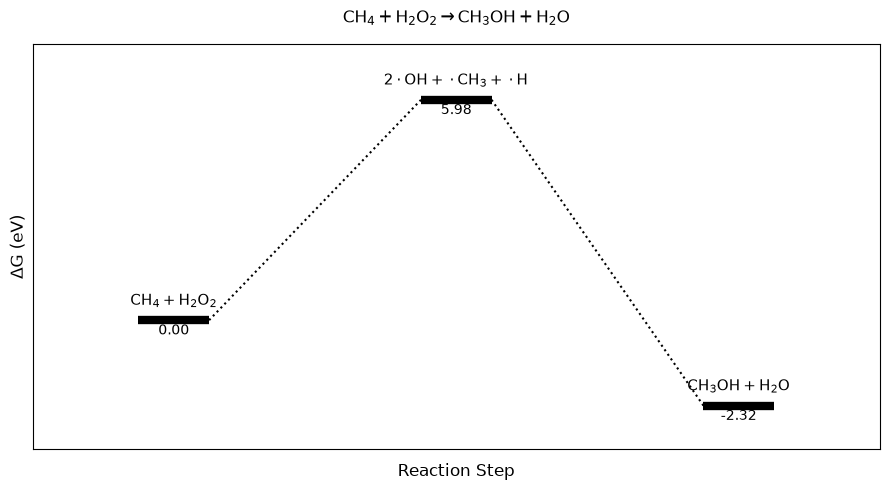

In [5]:
import matplotlib.pyplot as plt

# 1. Configurar los datos del perfil de energía (valores del eje Y)
pasos = [0, 1, 2]  # Posiciones en el eje X para cada estado
energias = [0.00, 5.98, -2.32]  # Valores de delta G en eV

# Etiquetas de texto para cada nivel y su valor numérico
etiquetas_quimicas = [r'$\text{CH}_4 + \text{H}_2\text{O}_2$', 
                      r'$2\cdot\text{OH} + \cdot\text{CH}_3 + \cdot\text{H}$', 
                      r'$\text{CH}_3\text{OH} + \text{H}_2\text{O}$']

valores_texto = ['0.00', '5.98', '-2.32']

# 2. Inicializar la figura con el estilo limpio de la imagen
fig, ax = plt.subplots(figsize=(9, 5))

# Ancho de las barras horizontales (niveles de energía)
ancho_barra = 0.25

# 3. Dibujar los niveles de energía y sus etiquetas
for i in range(len(pasos)):
    x = pasos[i]
    y = energias[i]
    
    # Dibujar la barra negra horizontal para el estado actual
    ax.hlines(y, x - ancho_barra/2, x + ancho_barra/2, colors='black', linewidth=6)
    
    # Colocar la fórmula química encima de la barra
    ax.text(x, y + 0.3, etiquetas_quimicas[i], ha='center', va='bottom', fontsize=11, color='black')
    
    # Colocar el valor numérico debajo de la barra
    ax.text(x, y - 0.1, valores_texto[i], ha='center', va='top', fontsize=10, color='black')

# 4. Dibujar las líneas punteadas de conexión entre los estados
for i in range(len(pasos) - 1):
    x_inicio = pasos[i] + ancho_barra/2
    x_fin = pasos[i+1] - ancho_barra/2
    y_inicio = energias[i]
    y_fin = energias[i+1]
    
    ax.plot([x_inicio, x_fin], [y_inicio, y_fin], color='black', linestyle=':', linewidth=1.5)

# 5. Configuración estética de los ejes y el recuadro exterior
ax.set_title(r'$\text{CH}_4 + \text{H}_2\text{O}_2 \rightarrow \text{CH}_3\text{OH} + \text{H}_2\text{O}$', fontsize=12, pad=15)
ax.set_ylabel(r'$\Delta\text{G (eV)}$', fontsize=12, fontweight='bold')
ax.set_xlabel('Reaction Step', fontsize=12, labelpad=10)

# Ajustar los límites de los ejes para que el recuadro encuadre bien los datos
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-3.5, 7.5)

# Ocultar las marcas numéricas de los ejes X e Y para igualar la imagen original
ax.set_xticks([])
ax.set_yticks([])

# Asegurar que el fondo del recuadro sea completamente blanco
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Mostrar la gráfica en el notebook
plt.tight_layout()
plt.show()


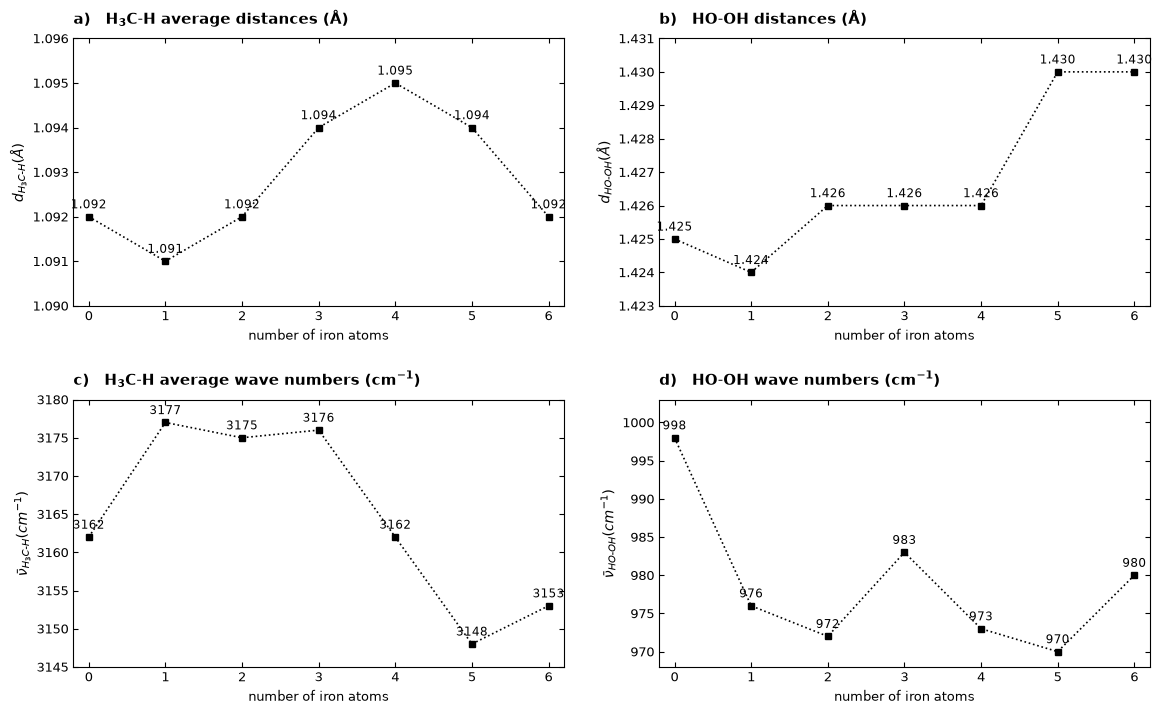

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos para los ejes X (número de átomos de hierro)
x = np.array([0, 1, 2, 3, 4, 5, 6])

# Datos para los ejes Y (puedes reemplazarlos por tus consultas de la BD de PostgreSQL)
y_a = np.array([1.092, 1.091, 1.092, 1.094, 1.095, 1.094, 1.092]) # H3C-H dist
y_b = np.array([1.425, 1.424, 1.426, 1.426, 1.426, 1.430, 1.430]) # HO-OH dist
y_c = np.array([3162, 3177, 3175, 3176, 3162, 3148, 3153])       # H3C-H wave
y_d = np.array([998, 976, 972, 983, 973, 970, 980])              # HO-OH wave

# 2. Configurar la matriz de subplots de 2x2
fig, axs = plt.subplots(2, 2, figsize=(12, 7.5), facecolor='white')

# Configuración de los 4 paneles
paneles = [
    {'ax': axs[0, 0], 'y': y_a, 'title': r'$\mathbf{a)\quad H_3C\text{-}H\ average\ distances\ (Å)}$', 'ylabel': r'$d_{H_3C\text{-}H} (Å)$', 'fmt': '{:.3f}'},
    {'ax': axs[0, 1], 'y': y_b, 'title': r'$\mathbf{b)\quad HO\text{-}OH\ distances\ (Å)}$', 'ylabel': r'$d_{HO\text{-}OH} (Å)$', 'fmt': '{:.3f}'},
    {'ax': axs[1, 0], 'y': y_c, 'title': r'$\mathbf{c)\quad H_3C\text{-}H\ average\ wave\ numbers\ (cm^{-1})}$', 'ylabel': r'$\bar{\nu}_{H_3C\text{-}H} (cm^{-1})$', 'fmt': '{:.0f}'},
    {'ax': axs[1, 1], 'y': y_d, 'title': r'$\mathbf{d)\quad HO\text{-}OH\ wave\ numbers\ (cm^{-1})}$', 'ylabel': r'$\bar{\nu}_{HO\text{-}OH} (cm^{-1})$', 'fmt': '{:.0f}'}
]

# 3. Dibujar cada panel dinámicamente
for p in paneles:
    ax = p['ax']
    ax.set_facecolor('white')
    
    # Graficar la línea punteada negra con marcadores cuadrados
    ax.plot(x, p['y'], color='black', linestyle=':', marker='s', markersize=5, linewidth=1.2)
    
    # Agregar las etiquetas numéricas flotantes sobre cada punto
    for xi, yi in zip(x, p['y']):
        texto = p['fmt'].format(yi)
        ax.annotate(texto, (xi, yi), textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8.5)
        
    # Ajustes estéticos de títulos y ejes
    ax.set_title(p['title'], loc='left', fontsize=11, pad=10)
    ax.set_ylabel(p['ylabel'], fontsize=10)
    ax.set_xlabel('number of iron atoms', fontsize=9.5)
    ax.set_xlim(-0.2, 6.2)
    ax.set_xticks(x)
    
    # Formato limpio sin cuadrícula de fondo
    ax.tick_params(direction='in', top=True, right=True, labelsize=9)

# 4. Ajustar límites específicos del eje Y para igualar la imagen original
axs[0, 0].set_ylim(1.090, 1.096)
axs[0, 1].set_ylim(1.423, 1.431)
axs[1, 0].set_ylim(3145, 3180)
axs[1, 1].set_ylim(968, 1003)

# Mostrar la composición de los 4 gráficos
plt.tight_layout(pad=2.0)
plt.show()


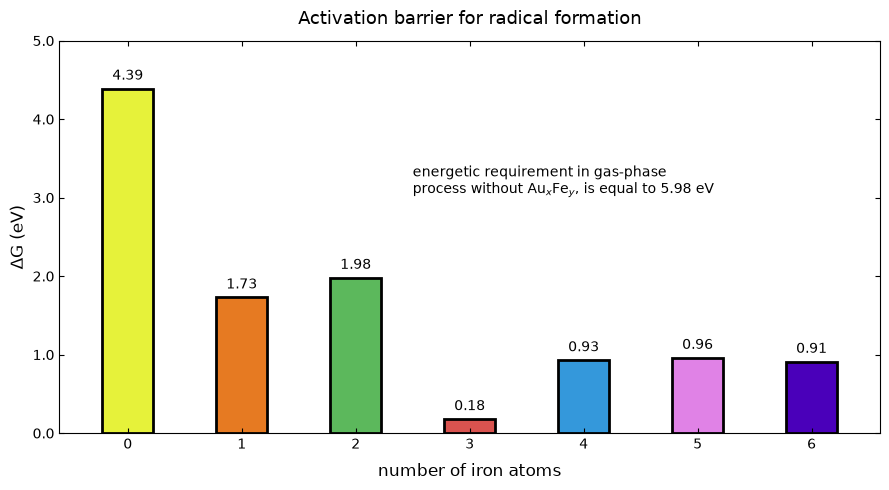

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurar los datos de la gráfica (Eje X y Eje Y)
x = np.array([0, 1, 2, 3, 4, 5, 6])
y = np.array([4.39, 1.73, 1.98, 0.18, 0.93, 0.96, 0.91])

# Paleta de colores exacta de la imagen para cada barra (formato Hexadecimal)
colores = ['#E6F23A', '#E67A22', '#5CB85C', '#D9534F', '#3498DB', '#E082E6', '#4A00BA']

# 2. Inicializar la figura con fondo blanco limpio
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')

# 3. Dibujar las barras con bordes negros marcados
# El ancho es de 0.45 para dejar espacio entre ellas como en el paper
barras = ax.bar(x, y, color=colores, edgecolor='black', linewidth=2, width=0.45)

# 4. Agregar el valor numérico en la parte superior de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.2f}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 4),  # Desplazamiento de 4 puntos hacia arriba
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# 5. Configurar el cuadro de texto flotante interno (Leyenda de fase gaseosa)
texto_interno = (
    "energetic requirement in gas-phase\n"
    "process without $\\text{Au}_x\\text{Fe}_y$, is equal to 5.98 eV"
)
ax.text(2.5, 3.2, texto_interno, fontsize=10, color='black', va='center')

# 6. Títulos, etiquetas de los ejes y límites del gráfico
ax.set_title("Activation barrier for radical formation", fontsize=13, pad=12)
ax.set_xlabel("number of iron atoms", fontsize=12, labelpad=8)
ax.set_ylabel("$\\Delta\\text{G (eV)}$", fontsize=12)

# Ajuste milimétrico de los ejes para que coincida con el formato del artículo
ax.set_xlim(-0.6, 6.6)
ax.set_ylim(0.0, 5.0)
ax.set_xticks(x)

# Marcas de los ejes apuntando hacia adentro (Estilo clásico de publicaciones científicas)
ax.tick_params(direction='in', top=True, right=True, labelsize=10)

# Asegurar que el formato de los decimales en el eje Y muestre un solo cero (.1f)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))

# Mostrar la composición final
plt.tight_layout()
plt.show()


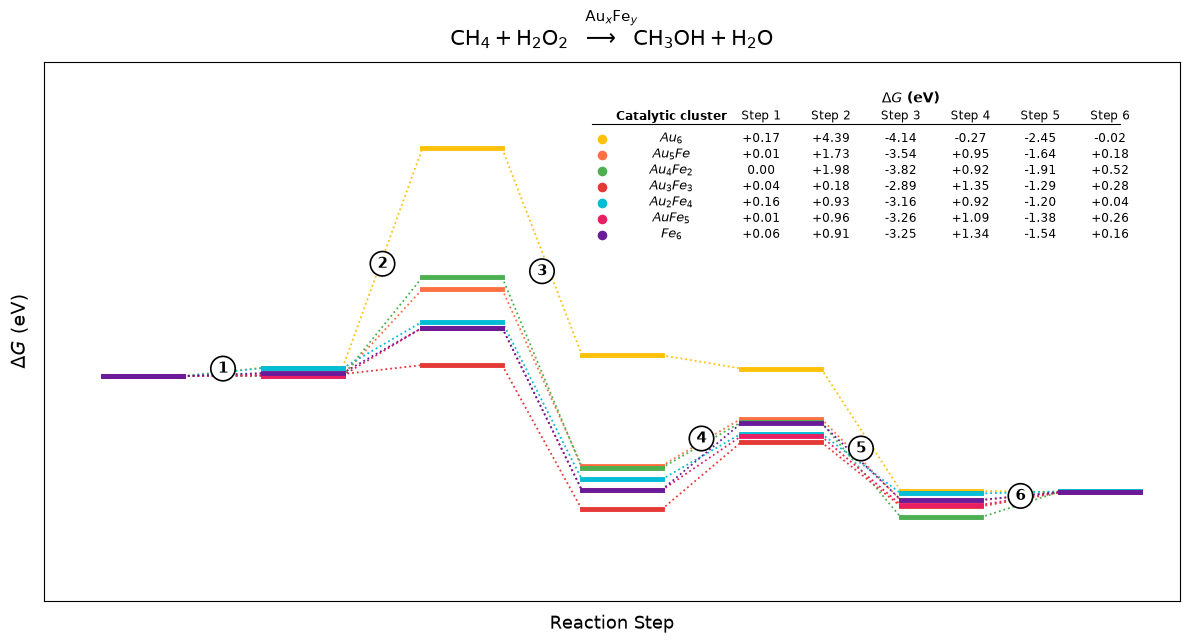

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Datos de la tabla CORREGIDOS (¡Gracias a tu descubrimiento!)
datos_pasos = {
    'Au6': [+0.17, +4.39, -4.14, -0.27, -2.45, -0.02],
    'Au5Fe': [+0.01, +1.73, -3.54, +0.95, -1.64, +0.18],
    'Au4Fe2': [0.00, +1.98, -3.82, +0.92, -1.91, +0.52], # ¡Corregido a +0.92!
    'Au3Fe3': [+0.04, +0.18, -2.89, +1.35, -1.29, +0.28],
    'Au2Fe4': [+0.16, +0.93, -3.16, +0.92, -1.20, +0.04],
    'AuFe5': [+0.01, +0.96, -3.26, +1.09, -1.38, +0.26],
    'Fe6': [+0.06, +0.91, -3.25, +1.34, -1.54, +0.16]
}

# Colores exactos de la imagen original
colores = {
    'Au6': '#FFC107',       # Amarillo/Dorado
    'Au5Fe': '#FF7043',     # Naranja claro
    'Au4Fe2': '#4CAF50',   # Verde original
    'Au3Fe3': '#E53935',   # Rojo
    'Au2Fe4': '#00BCD4',   # Cian
    'AuFe5': '#E91E63',     # Rosa/Magenta
    'Fe6': '#6A1B9A'        # Morado
}

# 2. Configuración de la figura
fig, ax = plt.subplots(figsize=(12, 6.5))

ancho_linea = 0.4
espacio = 0.4

# Dibujar los perfiles de energía libre (Lógica matemática pura, sin parches)
for cluster, pasos in datos_pasos.items():
    energias = [0.0]
    for p in pasos:
        energias.append(energias[-1] + p)
    
    color = colores[cluster]
    
    for i in range(len(energias)):
        x_inicio = i * (ancho_linea + espacio)
        x_fin = x_inicio + ancho_linea
        y = energias[i]
        
        # Graficar plataforma horizontal
        ax.plot([x_inicio, x_fin], [y, y], color=color, lw=3.5)
        
        # Graficar conexiones punteadas
        if i > 0:
            x_ant_fin = (i - 1) * (ancho_linea + espacio) + ancho_linea
            y_ant = energias[i - 1]
            ax.plot([x_ant_fin, x_inicio], [y_ant, y], color=color, linestyle=':', lw=1.3)

# 3. Dibujar la Tabla de forma manual
filas = list(datos_pasos.keys())

x_tabla_base = 2.45
y_tabla_base = 5.2
alto_fila = 0.32
ancho_col = 0.35

# Título de la tabla general (ΔG eV) centrado arriba de las columnas numéricas
ax.text(x_tabla_base + 1.6, y_tabla_base + 0.35, r'$\Delta G$ (eV)', fontsize=10, weight='bold', ha='center', va='center')

# Dibujar primer encabezado de columna
ax.text(x_tabla_base + 0.4, y_tabla_base, 'Catalytic cluster', weight='bold', fontsize=8.5, ha='center', va='center')

# Dibujar las etiquetas Step 1 a Step 6
for j in range(1, 7):
    ax.text(x_tabla_base + 0.5 + j * ancho_col, y_tabla_base, f'Step {j}', fontsize=8.5, ha='center', va='center')

# Línea divisoria horizontal negra debajo del encabezado
ax.plot([x_tabla_base, x_tabla_base + 0.5 + 6 * ancho_col + 0.05], [y_tabla_base - 0.15, y_tabla_base - 0.15], color='black', lw=0.8)

# Dibujar las filas con sus círculos de color y valores numéricos corregidos
for idx, fila in enumerate(filas):
    y_fila = y_tabla_base - 0.45 - idx * alto_fila
    
    # Círculo indicador de color
    ax.scatter(x_tabla_base + 0.05, y_fila, color=colores[fila], s=35, zorder=5)
    
    # Nombre químico formateado
    if fila == 'Au6': label_latex = r'$Au_6$'
    elif fila == 'Au5Fe': label_latex = r'$Au_5Fe$'
    elif fila == 'Au4Fe2': label_latex = r'$Au_4Fe_2$'
    elif fila == 'Au3Fe3': label_latex = r'$Au_3Fe_3$'
    elif fila == 'Au2Fe4': label_latex = r'$Au_2Fe_4$'
    elif fila == 'AuFe5': label_latex = r'$AuFe_5$'
    elif fila == 'Fe6': label_latex = r'$Fe_6$'
        
    ax.text(x_tabla_base + 0.4, y_fila, label_latex, fontsize=9, ha='center', va='center')
    
    # Valores numéricos alineados
    for j, val in enumerate(datos_pasos[fila]):
        val_str = f"+{val:.2f}" if val > 0 else (f"{val:.2f}" if val < 0 else "0.00")
        ax.text(x_tabla_base + 0.5 + (j + 1) * ancho_col, y_fila, val_str, fontsize=8.5, ha='center', va='center')

# 4. Posicionamiento de los círculos (1 al 6) CENTRADOS SOBRE LAS LÍNEAS PUNTEADAS
config_circulos = {
    '1': (0.60, 0.15),   
    '2': (1.40, 2.25),   
    '3': (2.20, 2.10),   
    '4': (3.00, -1.25),  
    '5': (3.80, -1.45),  
    '6': (4.60, -2.40)   
}

for num, (cx, cy) in config_circulos.items():
    ax.text(cx, cy, num, fontsize=11, weight='bold', ha='center', va='center', zorder=6,
            bbox=dict(boxstyle='circle,pad=0.3', facecolor='white', edgecolor='black', lw=1.2))

# 5. Formato de etiquetas, títulos y límites limpios
ax.set_ylabel(r'$\Delta G$ (eV)', fontsize=14, labelpad=10)
ax.set_xlabel('Reaction Step', fontsize=13, labelpad=10)

# Reacción química superior
ax.text(0.5, 1.04, r'$\mathrm{CH}_4 + \mathrm{H}_2\mathrm{O}_2 \ \ \longrightarrow \ \ \mathrm{CH}_3\mathrm{OH} + \mathrm{H}_2\mathrm{O}$', 
        fontsize=15, ha='center', va='center', transform=ax.transAxes)
ax.text(0.5, 1.08, r'$\mathrm{Au}_x\mathrm{Fe}_y$', 
        fontsize=11, ha='center', va='center', transform=ax.transAxes)

# Ocultar escalas numéricas nativas de los ejes
ax.set_xticks([])
ax.set_yticks([])

# Límites finales con aire hacia arriba y la derecha
ax.set_xlim(-0.3, 5.4)   
ax.set_ylim(-4.5, 6.3)   

plt.tight_layout()
plt.show()
